## Denoise Test Set

In [1]:
from pathlib import Path
from dotenv import load_dotenv
import sys
import os
sys.path.append('../denoising')

from networks import UNet, REDCNN
from data import PediatricIQDataset, MayoLDGCDataset

load_dotenv()

True

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from lightning import Trainer
from utils import circle_select


anthro = PediatricIQDataset(os.environ['PEDIATRICIQ_PATH'], phantom='anthropomorphic', subgroup='child')

def show_examples(model, dset):
    x, y = dset[0]
    with torch.no_grad():
        pred = model(torch.tensor(x[None]).float()).squeeze()
    x = x.squeeze()
    y = y.squeeze()
    ww, wl = 150, 30
    xy = (200, 200)
    r = 40
    
    disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
    f, axs = plt.subplots(1, 3, dpi=300, gridspec_kw=dict(wspace=0, hspace=0))
    for ax, im in zip(axs.flatten(), [x, y, pred]):
        roi = circle_select(im, xy, r)
        ax.imshow(im, **disp)
        ax.imshow(roi, alpha=0.1, cmap='Blues')
        ax.set_title(f'mean | std: {im[roi].mean():2.0f} | {im[roi].std():2.0f} HU', fontsize=6)
        ax.set_axis_off()
    plt.show()

unet = UNet.load_from_checkpoint('/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/head_denoising/lightning_logs/version_6096277/checkpoints/epoch=99-step=166800.ckpt')
redcnn = REDCNN.load_from_checkpoint('/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/head_denoising/lightning_logs/version_6102376/checkpoints/epoch=99-step=166800.ckpt')

model = redcnn
show_examples(model, AnthropomorphicDataset(os.environ['ANTHROPOMORPHIC_PATH'], subgroup='adult'))
show_examples(model, AnthropomorphicDataset(os.environ['ANTHROPOMORPHIC_PATH'], subgroup='child'))
show_examples(model, AnthropomorphicDataset(os.environ['ANTHROPOMORPHIC_PATH'], subgroup='newborn'))

model = unet
show_examples(model, AnthropomorphicDataset(os.environ['ANTHROPOMORPHIC_PATH'], subgroup='adult'))
show_examples(model, AnthropomorphicDataset(os.environ['ANTHROPOMORPHIC_PATH'], subgroup='child'))
show_examples(model, AnthropomorphicDataset(os.environ['ANTHROPOMORPHIC_PATH'], subgroup='newborn'))

You could

model = redcnn
show_examples(model, PediatricIQDataset(os.environ['PEDIATRICIQ_PATH'], subgroup='adult'))
show_examples(model, PediatricIQDataset(os.environ['PEDIATRICIQ_PATH'], subgroup='child'))
show_examples(model, PediatricIQDataset(os.environ['PEDIATRICIQ_PATH'], subgroup='newborn'))

model = unet
show_examples(model, PediatricIQDataset(os.environ['PEDIATRICIQ_PATH'], subgroup='adult'))
show_examples(model, PediatricIQDataset(os.environ['PEDIATRICIQ_PATH'], subgroup='child'))
show_examples(model, PediatricIQDataset(os.environ['PEDIATRICIQ_PATH'], subgroup='newborn'))

Interesting, the UNET does better when its closer to its training distribution (more anthropomorphic) but crumbles on phantoms, whereas REDCNN is simpler and doesn't preserve sharpness as well as UNet, its fuzzier but is more generalizable due to its simplicity.

Can make a similar argument with the anthropomorphic on the newborn, you get those weird spikes.

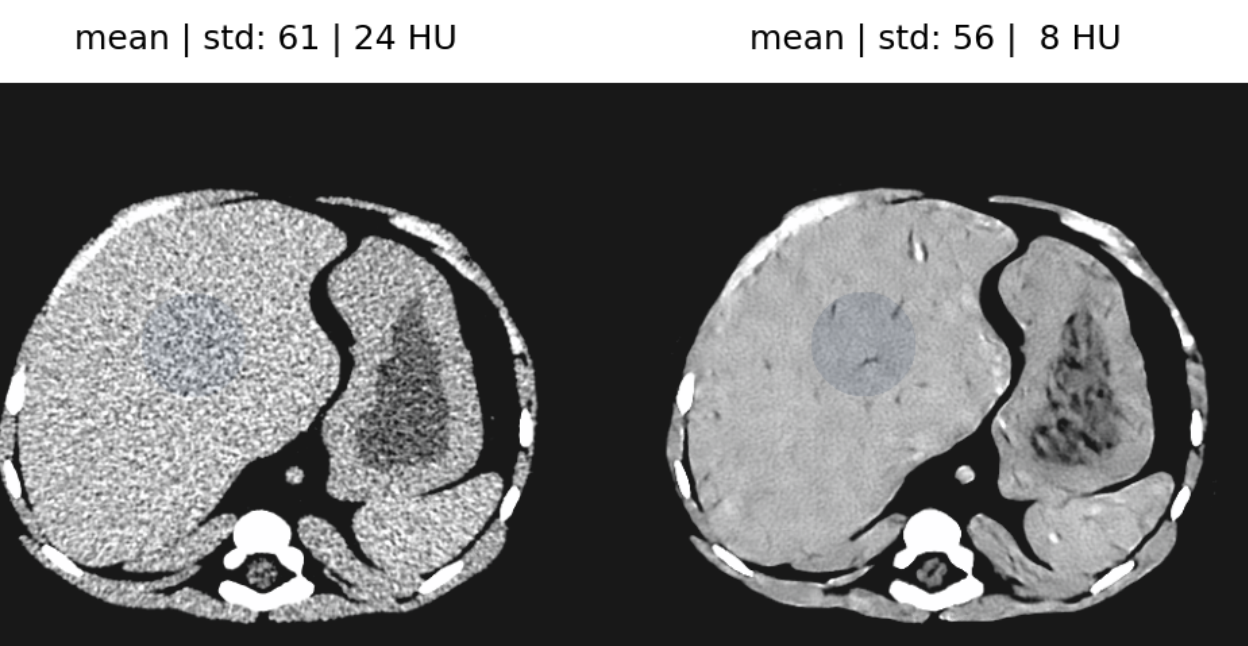

That you don't see with REDCNN, its just less denoised:

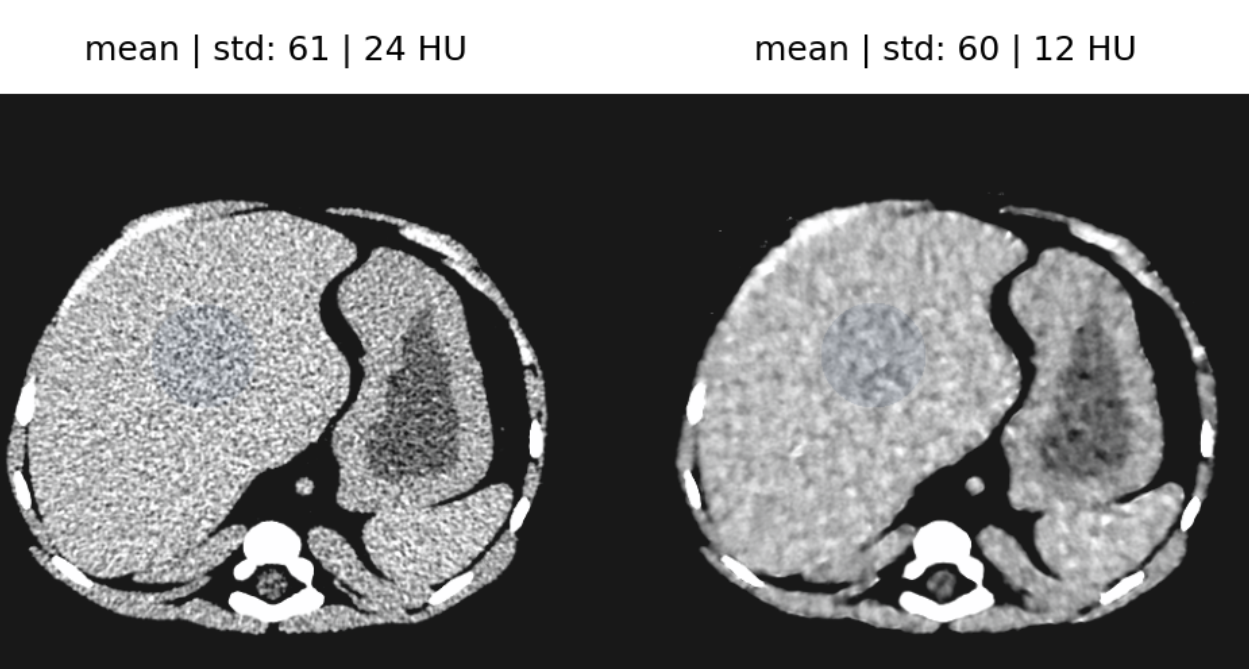

# fnames = trainer.predict(model=model, dataloaders=(anthro, peds))

Explore adding DataModules for the anthro and peds and can cut down on code even more as it looks like the trainer can load multiple dataloaders (and models?) better following pytorch lightning paradigms will make my life easier

In [8]:
from pathlib import Path
from utils import study_viewer, browse_studies
from get_experiment_metadata import get_pediatric_metadata

base_dir = Path('/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/denoising/lightning_logs/')
experiment_dir = base_dir / '2025-03-09_19-40_ldgc_abdomen'
metadata = get_pediatric_metadata(experiment_dir)
metadata['Name'] = metadata.name
metadata['instance'] = metadata['slice']
study_viewer(metadata.sort_values(by='recon'))

interactive(children=(Dropdown(description='phantom', options=('CTP404', 'uniform', 'anthropomorphic', 'MITA-L…